# Hotspot calculation and slide plots

In [ ]:
## Import packages
import scanpy as sc
import anndata as ad
import os
import numpy as np
import sys
import spottedpy as sp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squidpy as sq
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

In [ ]:
# Read in anndata visium object
path="/Users/spalominoe/Python_jobs/01_scripts/TNBC_spatial.h5ad"
TNBC=sc.read_h5ad(path)

In [57]:
# Subset the AnnData object for batches that correspond to the TNBC samples "CID4465"= 6  ;"CID44971"= 9
sample_CID44971 = TNBC[TNBC.obs['batch'] == '9']
sample_CID4465 = TNBC[TNBC.obs['batch'] == '6']

In [58]:
# Areas for signatures
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scanpy as sc
import numpy as np

# Define your custom colormap (lightblue, white, darkorange)
colors = ["lightblue", "white", "darkorange"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

# Define your samples in a dictionary {sample_name: batch_number}
samples = {
    "CID44971": "9",
    "CID4465": "6",
}

# Loop through each sample
for sample_name, batch_num in samples.items():
    # Extract the sample based on batch
    sample_data = TNBC[TNBC.obs['batch'] == batch_num]

    # Rescale the expression of 'oxstress' (or any other variable)
    oxstress_expression = sample_data.obs["oxstress"]  # Assuming 'oxstress' is stored in `obs`
    
    # Normalize the expression so the highest value is 1 and the lowest is 0
    oxstress_rescaled = (oxstress_expression - np.min(oxstress_expression)) / (np.max(oxstress_expression) - np.min(oxstress_expression))

    # Store the rescaled expression back into the sample data
    sample_data.obs["oxstress_rescaled"] = oxstress_rescaled
    
    
    
    # Rescale the expression of 'GCLCVIM' 
    GCLCVIM_expression = sample_data.obs["GCLCVIM_tumor"]  # Assuming 'oxstress' is stored in `obs`
    
    # Normalize the expression so the highest value is 1 and the lowest is 0
    GCLCVIM_rescaled = (GCLCVIM_expression - np.min(GCLCVIM_expression)) / (np.max(GCLCVIM_expression) - np.min(GCLCVIM_expression))

    # Store the rescaled expression back into the sample data
    sample_data.obs["GCLCVIM_rescaled"] = GCLCVIM_rescaled


    # Generate and save spatial plots
    for plot_type, params in [
        ("slide", {"spot_size": 100}),
        ("oxstress_enriched_areas", {"spot_size": 10, "color": "oxstress_rescaled", "size": 10, "cmap": cmap}),  # Use custom colormap and rescaled expression
        ("GCLCVIM_enriched_areas", {"spot_size": 10, "color": "GCLCVIM_rescaled", "size": 10, "cmap": cmap})
    ]:
        # Create figure and axis
        fig, ax = plt.subplots()

        # Generate the spatial plot
        sc.pl.spatial(sample_data, library_id=batch_num, img_key='hires', ax=ax, show=False, **params)

        # Modify the transparency of the H&E background image
        img = ax.get_images()[0]  # The background image is usually the first image
        img.set_alpha(0.8)  # Set transparency (0 = fully transparent, 1 = opaque)

        # Save the plot
        filename = f"{sample_name}_{plot_type}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()  # Close the plot to free memory

        print(f"Saved {filename}")


Saved CID44971_slide.pdf
Saved CID44971_oxstress_enriched_areas.pdf
Saved CID44971_GCLCVIM_enriched_areas.pdf
Saved CID4465_slide.pdf
Saved CID4465_oxstress_enriched_areas.pdf
Saved CID4465_GCLCVIM_enriched_areas.pdf


In [59]:
#### HOTSPOTS 
# It is the values in the .obs columns that we are interested in calculating hotspots from
celltypes_labels=['B_cells_total'  ,'CAFs_total',  'Cancer_total', 'Endothelial_total',	'Luminal_total','Myeloid_total',
                'Myoepithelia_total',	'PVL_total',	'TCD4_total',	'TCD8_total',	'NK_total',	'Plasmablasts_total']

signature_labels=['oxstress', 'GCLCVIM_tumor']


# Create hotspots for our oxstress and GCLCVIM values and the different cell types values.
for i in tqdm(celltypes_labels):
    TNBC=sp.create_hotspots(TNBC,column_name=i,neighbours_parameters=10,relative_to_batch=True)
    

for i in tqdm(signature_labels):
    TNBC=sp.create_hotspots(TNBC,filter_value=1,column_name=i,neighbours_parameters=10,relative_to_batch=True)
    
    
# Loop through cell types and add "_hot" to the end of each one so we calculate distances from them
celltypes_labels_hotspots=celltypes_labels.copy()

for i in range(0,len(celltypes_labels)):
    celltypes_labels_hotspots[i]=celltypes_labels[i]+'_hot'

100%|██████████| 2/2 [00:01<00:00,  1.21it/s]


In [60]:
def plot_hotspot(anndata, column_name, batch_single, save_path, color_for_spots, spot_size=10):
    if batch_single is not None:
        data_subset = anndata[anndata.obs['batch'] == str(batch_single)].copy()
        sc.pl.spatial(data_subset, color=[column_name], vmax='p0', color_map=color_for_spots,
                      library_id=str(batch_single), save=f"_{save_path}", colorbar_loc=None, alpha_img=0.5, s=spot_size**2)
    else:
        for batch in anndata.obs['batch'].unique():
            data_subset = anndata[anndata.obs['batch'] == str(batch)].copy()
            sc.pl.spatial(data_subset, color=[column_name], vmax='p0', color_map=color_for_spots,
                          library_id=str(batch), save=f"_{str(batch)}_{save_path}", colorbar_loc=None, alpha_img=0.5, s=spot_size**2)


In [61]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define a custom colormap
color_for_spots_1 = ListedColormap(['red'])
color_for_spots_2 = ListedColormap(['blue'])



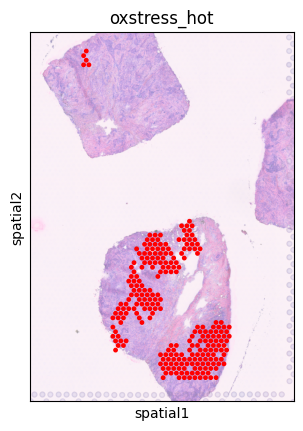

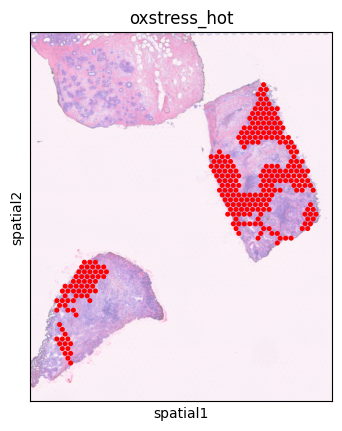

In [62]:
plot_hotspot(TNBC, column_name="oxstress_hot", batch_single=None, save_path="spatial_plot", color_for_spots=color_for_spots_1, spot_size=3.2)


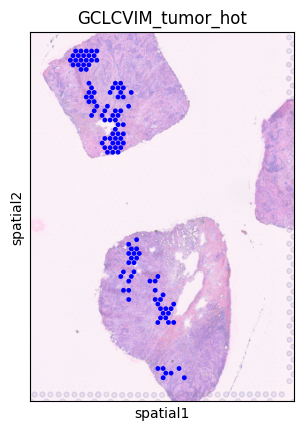

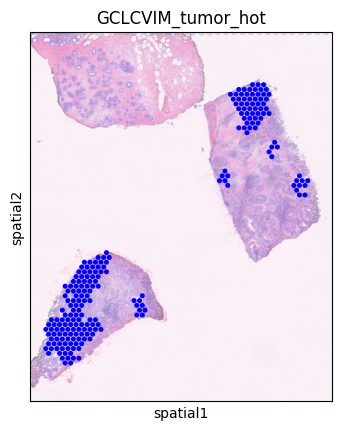

In [63]:
plot_hotspot(TNBC, column_name="GCLCVIM_tumor_hot", batch_single=None, save_path="spatial_plot", color_for_spots=color_for_spots_2, spot_size=3.2)


In [64]:
# Compute distances
#primary variables are the hotspots we calculate distances from
#comparison variables are the hotspots we calculate distances to
primary_variables_values=['oxstress_hot', 'GCLCVIM_tumor_hot']

distances=sp.calculateDistances(TNBC,primary_variables=primary_variables_values,comparison_variables=celltypes_labels_hotspots,empty_hotspot_default_to_max_distance=True)

In [65]:
distances.to_csv("distances.csv")

### Pie proportions

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def plot_spatial_scatterpie(TNBC, sample_name, batch_number, x, y, 
                             cell_types=None, img=None, scatterpie_alpha=1, 
                             pie_scale=0.4, degrees=None, axis=None,
                             show_labels=True, output_file=None, figsize=(10, 10)):
    """
    Plots a spatial scatterpie chart with the legend outside.

    Parameters:
    - TNBC: AnnData object containing spatial data.
    - sample_name: Name of the sample to plot.
    - batch_number: Batch number to filter the dataset.
    - x: DataFrame or ndarray, coordinates of spots (must contain ['coord_x', 'coord_y']).
    - y: DataFrame or ndarray, proportions of cell types. Row indices must match `x`.
    - cell_types: List of cell types to plot. Default is all columns in `y`.
    - img: Background image to plot. Default is None.
    - scatterpie_alpha: Alpha transparency for pie charts. Default is 1.
    - pie_scale: Scaling factor for pie chart size. Default is 0.4.
    - degrees: Rotation angle for the image (if provided). Default is None.
    - axis: Axis for mirroring the image ('h' for horizontal, 'v' for vertical). Default is None.
    - show_labels: bool, whether to show labels for cell types.
    - output_file: File path to save the plot as a PDF. Default is None.
    - figsize: Tuple, size of the figure. Default is (10, 10).

    Returns:
    - A matplotlib plot.
    - If `output_file` is provided, the plot is saved with a filename including sample and batch.
    """

    # Filter the dataset for the specific sample and batch
    sample_data = TNBC[TNBC.obs['batch'] == str(batch_number)]
    
    if sample_data.shape[0] == 0:
        raise ValueError(f"No data found for sample '{sample_name}' with batch '{batch_number}'.")

    # Convert inputs to DataFrame if necessary
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=['coord_x', 'coord_y'])

    if isinstance(y, np.ndarray):
        y = pd.DataFrame(y)

    # Validate inputs
    if not set(['coord_x', 'coord_y']).issubset(x.columns):
        raise ValueError("`x` must contain 'coord_x' and 'coord_y' columns.")

    if cell_types is None:
        cell_types = y.columns.tolist()

    if len(cell_types) > y.shape[1]:
        raise ValueError("Length of `cell_types` exceeds number of columns in `y`.")

    if not np.all(x.index == y.index):
        raise ValueError("Indices of `x` and `y` must match.")

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    if img is not None:
        ax.imshow(img, extent=[x['coord_x'].min(), x['coord_x'].max(),
                               x['coord_y'].min(), x['coord_y'].max()],
                  aspect='auto')
    
    patches = []
    colors = plt.cm.tab20(np.linspace(0, 1, len(cell_types)))
    
    for i, (coord_x, coord_y) in x.iterrows():
        proportions = y.loc[i, cell_types]
        proportions /= proportions.sum()

        start_angle = 0
        for j, proportion in enumerate(proportions):
            if proportion > 0:
                end_angle = start_angle + 360 * proportion
                wedge = Wedge((coord_x, coord_y), pie_scale, start_angle, end_angle, 
                              color=colors[j], alpha=scatterpie_alpha)
                patches.append(wedge)
                start_angle = end_angle

    patch_collection = PatchCollection(patches, match_original=True)
    ax.add_collection(patch_collection)

    ax.set_xlim(x['coord_x'].min() - pie_scale, x['coord_x'].max() + pie_scale)
    ax.set_ylim(x['coord_y'].min() - pie_scale, x['coord_y'].max() + pie_scale)
    ax.set_aspect('equal')

    # Add legend for cell types (outside the plot)
    if show_labels:
        legend_patches = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
            for color in colors
        ]
        ax.legend(
            legend_patches, cell_types, 
            loc='center left',  # Position legend to the right
            bbox_to_anchor=(1.05, 0.5),  # Moves legend outside the plot
            title="Cell Types",
            frameon=False  # Optional: Removes legend border
        )

    ax.invert_yaxis()
    ax.axis('off')

    # Generate automatic filename if not provided
    if output_file is None:
        output_file = f"{sample_name}_batch_{batch_number}_scatterpie.pdf"

    plt.savefig(output_file, format='pdf', bbox_inches='tight')
    plt.close()

    print(f"Plot saved as {output_file}")


In [67]:
def get_hotspots_for_sample(TNBC, sample_name, batch_number, scale_factor=50):
    """
    Extracts hotspot coordinates for a specific sample and batch.

    Parameters:
    - TNBC: AnnData object containing spatial data.
    - sample_name: The sample to filter.
    - batch_number: The batch to filter.
    - scale_factor: Scaling factor for coordinates (default=50).

    Returns:
    - DataFrame with filtered hotspot coordinates.
    """
    # Filter dataset for the specific sample and batch
    sample_data = TNBC[TNBC.obs['batch'] == str(batch_number)]
    
    if sample_data.shape[0] == 0:
        raise ValueError(f"No data found for sample '{sample_name}' with batch '{batch_number}'.")

    # Select only hotspot indices where "oxstress_hot" > 0
    hotspots_index = sample_data.obs[
    (sample_data.obs["oxstress_hot"] >= 0) | (sample_data.obs["oxstress_hot"].isna())].index
    # Extract coordinates and filter only for hotspot indices
    hotspots_coords = pd.DataFrame(
        sample_data.obsm['spatial'], index=sample_data.obs.index, columns=['coord_x', 'coord_y']
    ).loc[hotspots_index]

    # Scale coordinates
    hotspots_coords['coord_x'] /= scale_factor
    hotspots_coords['coord_y'] /= scale_factor

    return hotspots_coords


In [68]:
def get_cell_type_proportions(TNBC, sample_name, batch_number, hotspots_index):
    """
    Extracts cell type proportions for a specific sample, batch, and hotspot indices.

    Parameters:
    - TNBC: AnnData object containing spatial data.
    - sample_name: The sample to filter.
    - batch_number: The batch to filter.
    - hotspots_index: Filtered hotspot indices from get_hotspots_for_sample().

    Returns:
    - DataFrame with filtered cell type proportions matching hotspots.
    """
    # Filter dataset for the specific sample and batch
    sample_data = TNBC[TNBC.obs['batch'] == str(batch_number)]
    
    if sample_data.shape[0] == 0:
        raise ValueError(f"No data found for sample '{sample_name}' with batch '{batch_number}'.")

    # Extract cell type proportions (matching indices)
    normalized_subset = pd.DataFrame(sample_data.obsm['normalized_subset'], index=sample_data.obs.index)

    # List of relevant cell types
    cell_types = [
        'B_cells_total', 'CAFs_total', 'Cancer_total', 'Endothelial_total', 'Luminal_total',
        'Myeloid_total', 'Myoepithelia_total', 'PVL_total', 'TCD4_total', 'TCD8_total',
        'NK_total', 'Plasmablasts_total'
    ]

    # Selecting only relevant cell types and aligning with hotspot indices
    hotspots_y = normalized_subset[cell_types].loc[hotspots_index]

    return hotspots_y


In [69]:
# Get hotspots for the specific sample
hotspots_coords = get_hotspots_for_sample(TNBC, sample_name="CID44971", batch_number="9")

# Get cell type proportions, matching the hotspot indices
hotspots_y = get_cell_type_proportions(TNBC, "CID44971", "9", hotspots_coords.index)

# Generate scatterpie plot with filtered data
plot_spatial_scatterpie(
    TNBC,
    sample_name="CID44971",
    batch_number="9",
    x=hotspots_coords,  # Filtered coordinates
    y=hotspots_y,       # Filtered cell type proportions
    cell_types=[
        'B_cells_total', 'CAFs_total', 'Cancer_total', 'Endothelial_total', 'Luminal_total',
        'Myeloid_total', 'Myoepithelia_total', 'PVL_total', 'TCD4_total', 'TCD8_total',
        'NK_total', 'Plasmablasts_total'
    ],
    pie_scale=0.8,
    figsize=(5, 5)
)


Plot saved as CID44971_batch_9_scatterpie.pdf


In [70]:
# Get hotspots for the specific sample
hotspots_coords = get_hotspots_for_sample(TNBC, sample_name="CID4465", batch_number="6")

# Get cell type proportions, matching the hotspot indices
hotspots_y = get_cell_type_proportions(TNBC, "CID4465", "6", hotspots_coords.index)

# Generate scatterpie plot with filtered data
plot_spatial_scatterpie(
    TNBC,
    sample_name="CID4465",
    batch_number="6",
    x=hotspots_coords,  # Filtered coordinates
    y=hotspots_y,       # Filtered cell type proportions
    cell_types=[
        'B_cells_total', 'CAFs_total', 'Cancer_total', 'Endothelial_total', 'Luminal_total',
        'Myeloid_total', 'Myoepithelia_total', 'PVL_total', 'TCD4_total', 'TCD8_total',
        'NK_total', 'Plasmablasts_total'
    ],
    pie_scale=0.8,
    figsize=(5, 5)
)


Plot saved as CID4465_batch_6_scatterpie.pdf
